Note: code snippets and content are based on course from DataCamp. Also some content are AI generated.


# Part 1: Introduction to FastAPI for model deployment


## Get and Post requests for AI

GET requests are built to retrieve data. In APIs, we often include extra information within the URL itself, like an item ID. This is called a path parameter. A GET request doesn't change anything in the database - it is read-only.

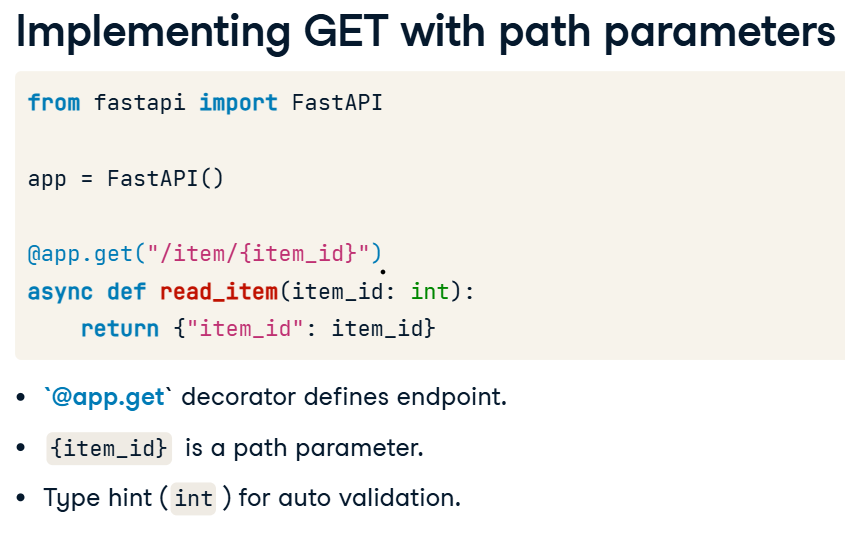

POST requests send a data payload to the server, usually to create or update something. This data typically comes in the form of a JSON request body. POST requests can update data and change server state.

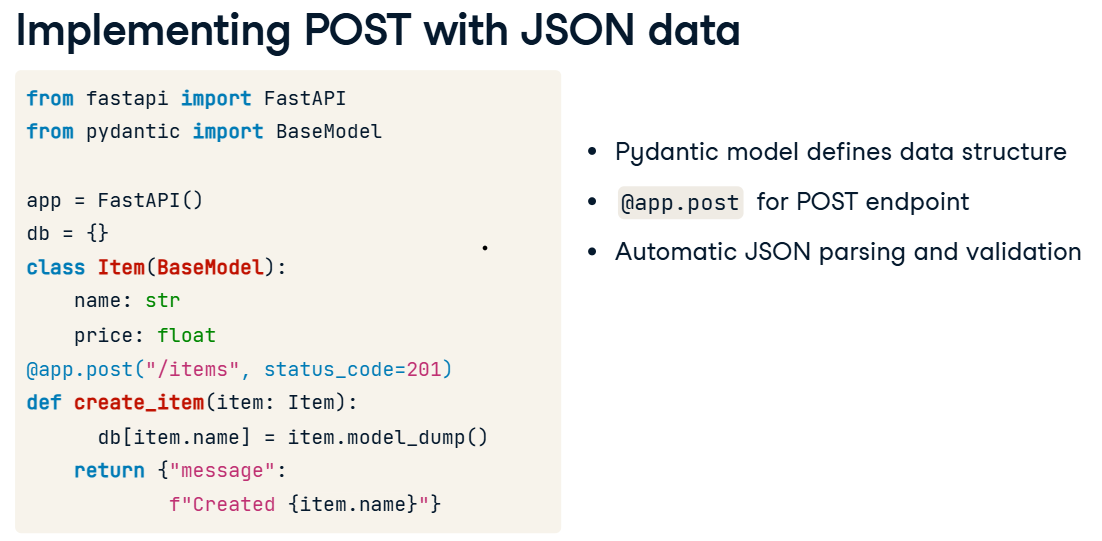



## FastAPI prediction with a pretrained model

To create a FastAPI app for serving ML predictions, we need three key libraries: FastAPI for the API, uvicorn as the Asynchronous Server Gateway Interface or ASGI server for handling concurrent requests, and joblib to load pre-trained models.

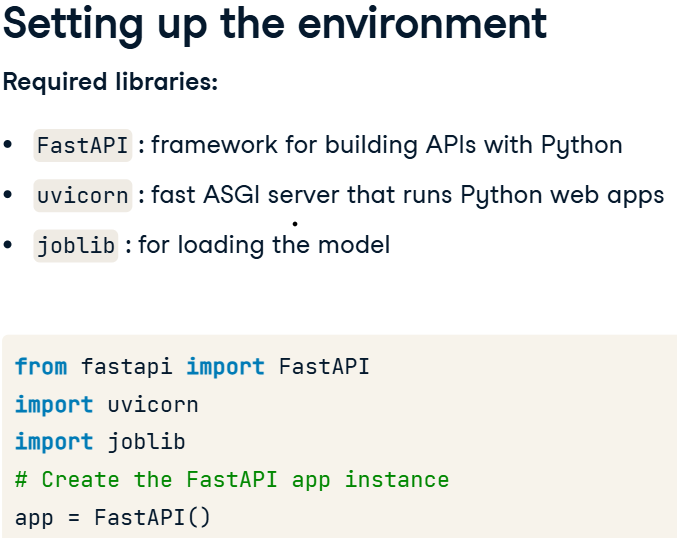

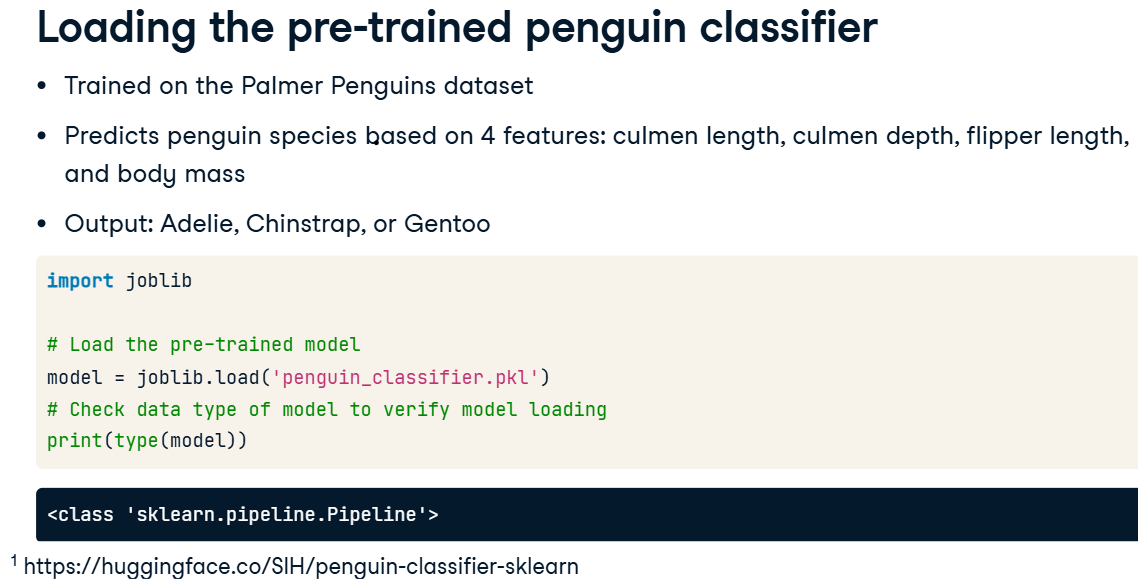

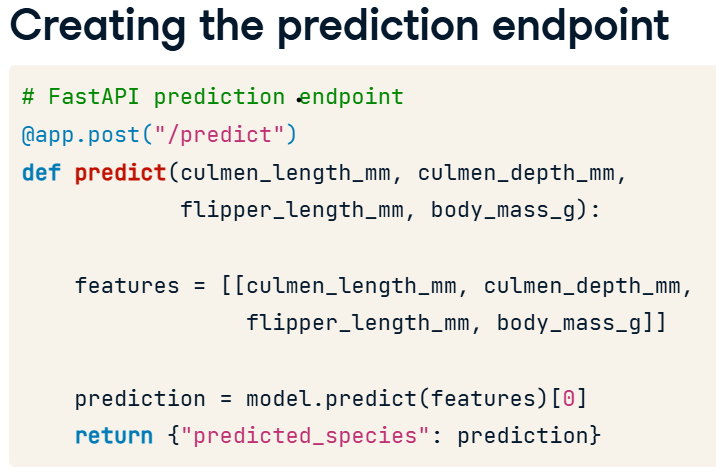

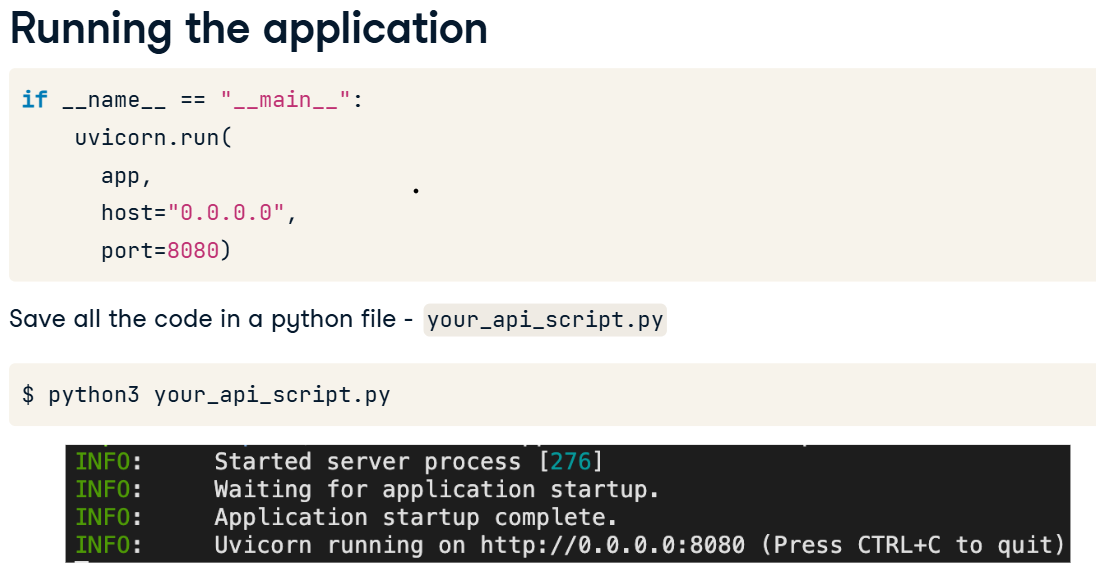

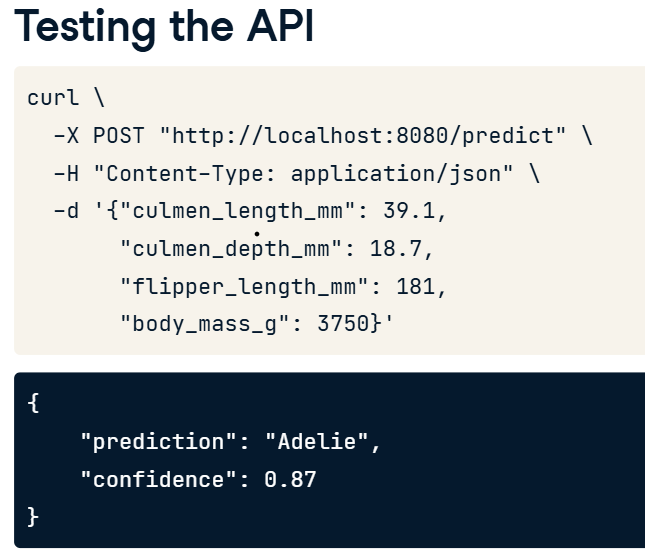

### ✅ What does if __name__ == "__main__" mean?
In Python, every file/module has a built-in variable called __name__.

When a file is run directly (e.g., python my_script.py), Python sets __name__ = "__main__".

When a file is imported as a module (e.g., import my_script), Python sets __name__ = "my_script" (i.e., the filename, without .py).

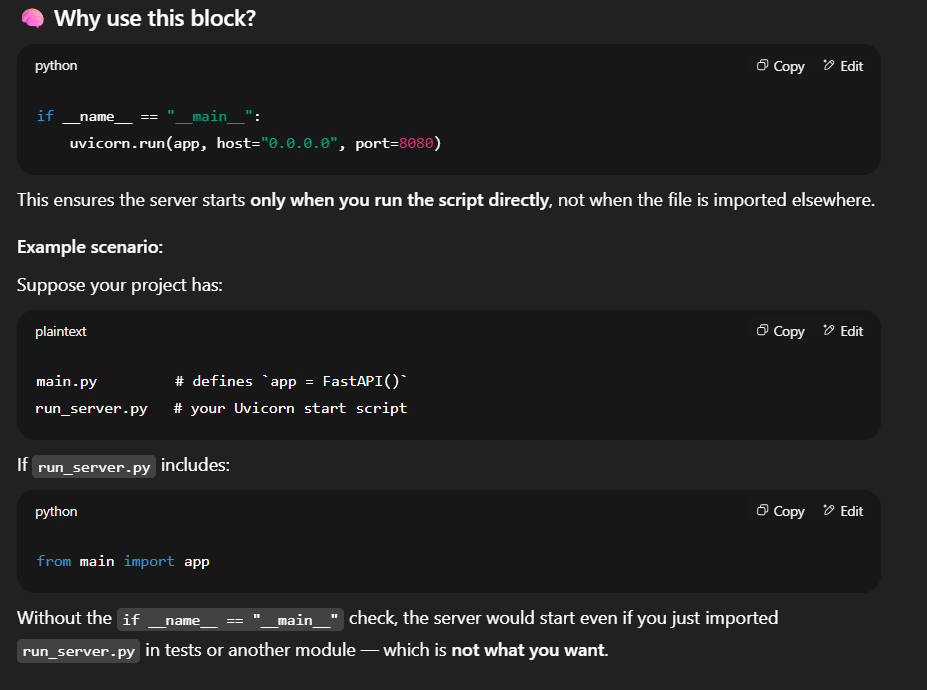

🧪 Analogy:
Think of it like this:

"if __name__ == "__main__" is like saying: only do this if you're the main program, not just a helper being used by another program."

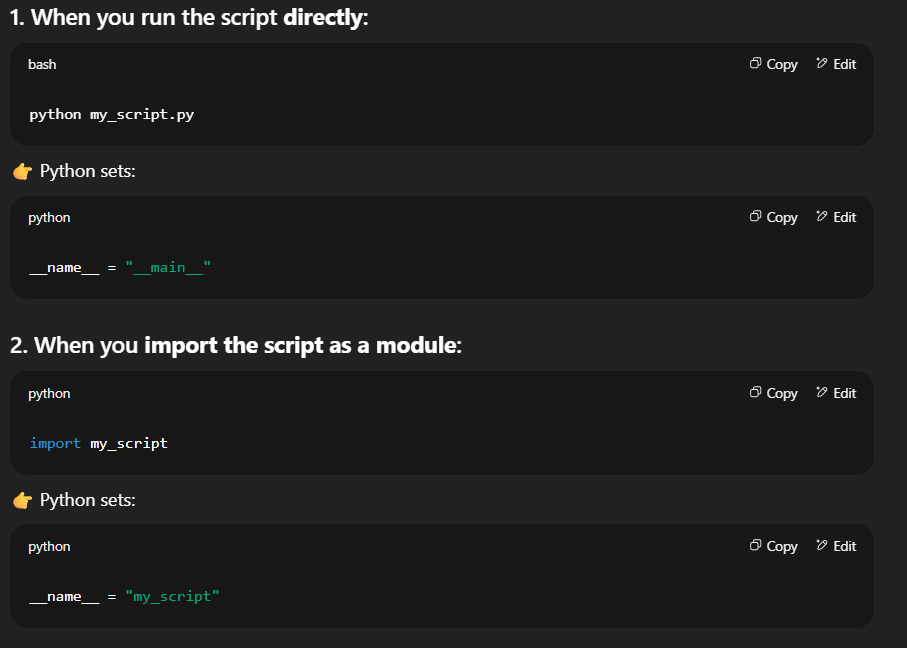

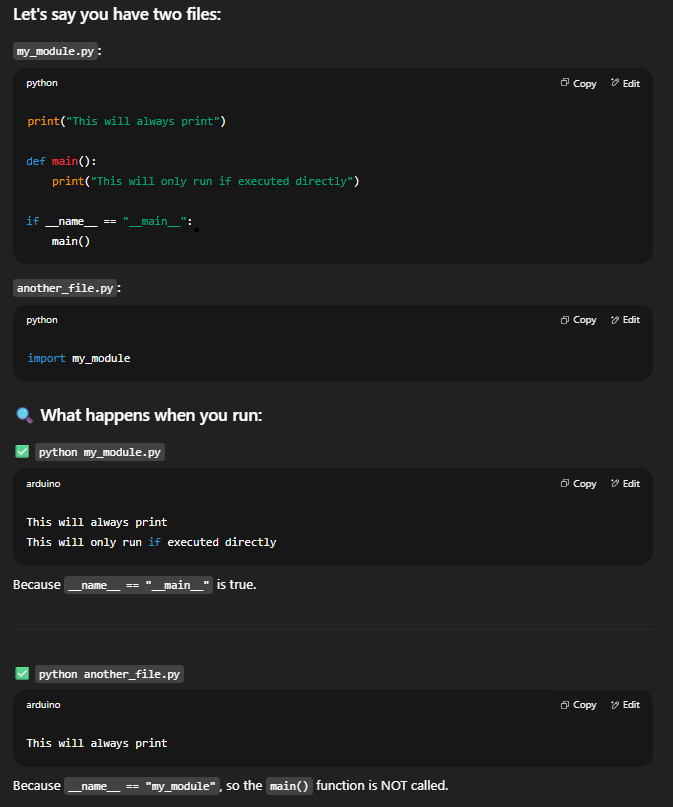

## request and response models

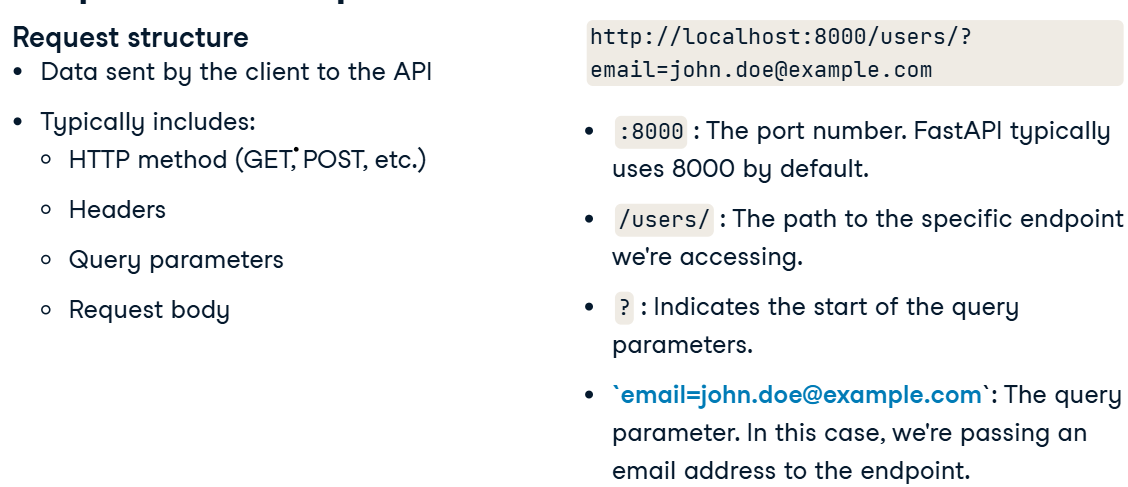

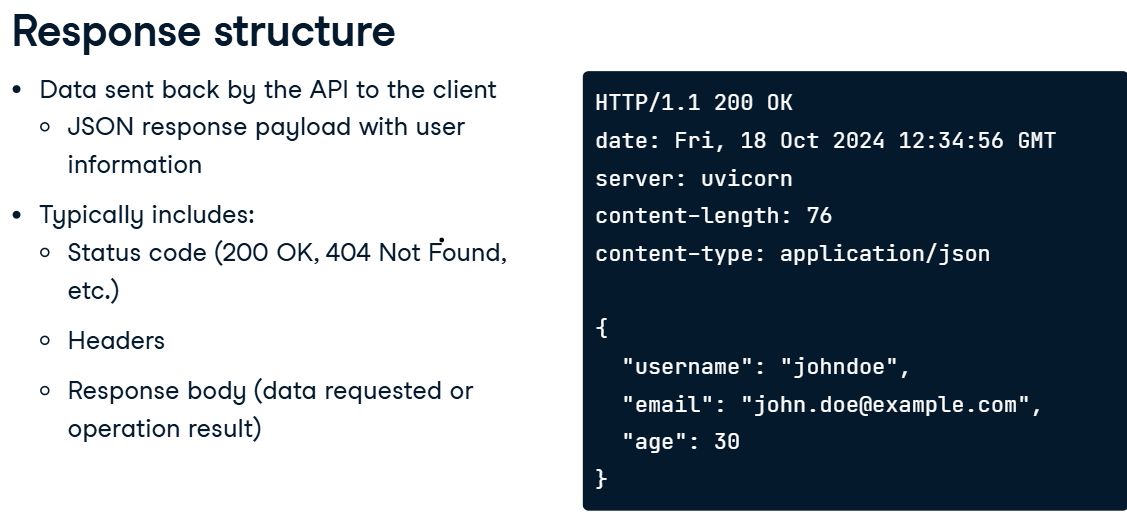

Pydantic models are used to maintain well-structured nested models for HTTP transactions.First, we import BaseModel from Pydantic. Our User class inherits from BaseModel, and then we define our attributes using Python type annotations.

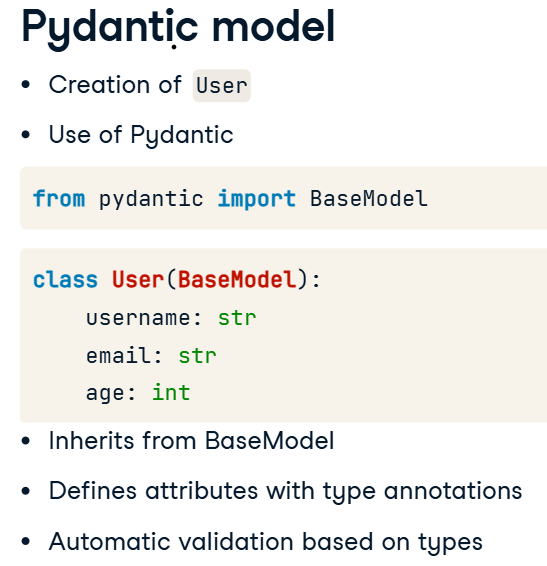

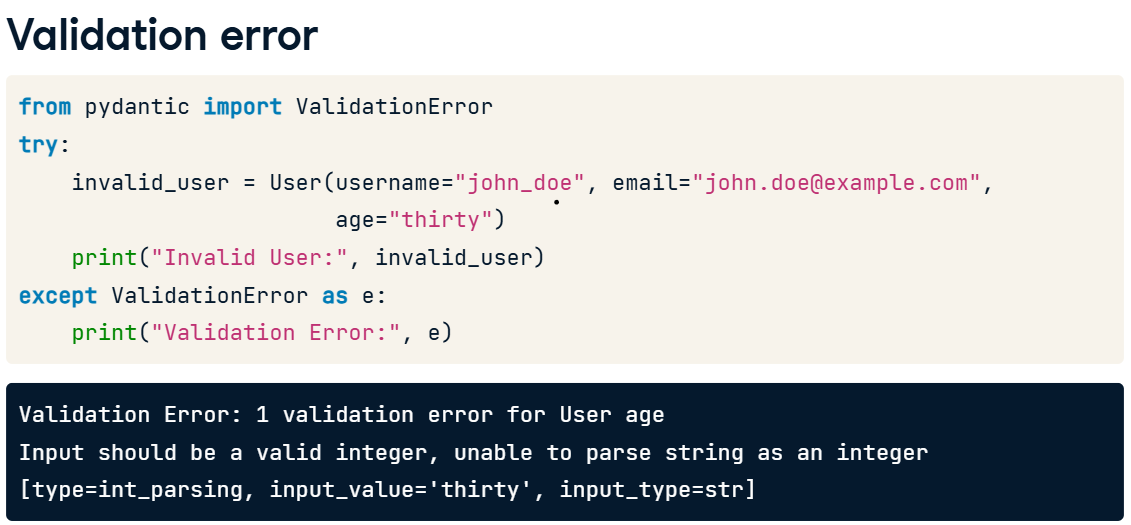

Now, let's see this Pydantic model in action with a FastAPI app. First, we create a FastAPI app after importing the required libraries and classes. Then we create a Pydantic model which will be used in our user creation endpoint. Now to create the endpoint, we add an @app.post decorator with the User model as response_model. This is FastAPI's way of saying, "When I send back a response, make sure it also follows the User model." Then we use the same model as a type hint for the user input to the create_user function. The pydantic model provides a defined structure to validate requests. Under the hood, FastAPI also relies on Pydantic models to deserialize and serialize requests and responses, and generate documentation.

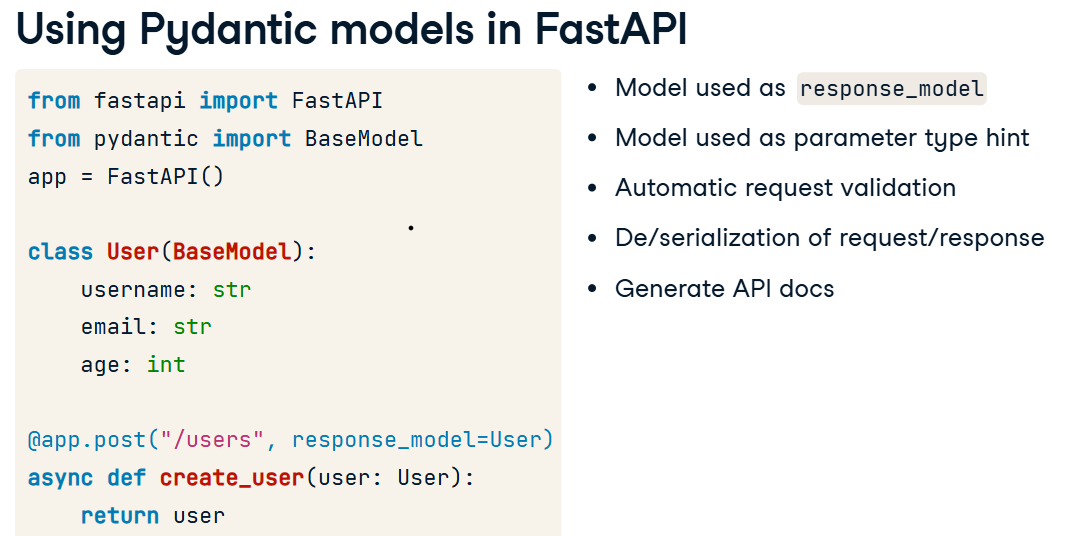

To check the request structure, we can send a POST request using cURL. We have specified the headers, content type and then the user details as JSON body. We get automatic request validation and response payload as JSON from the API.

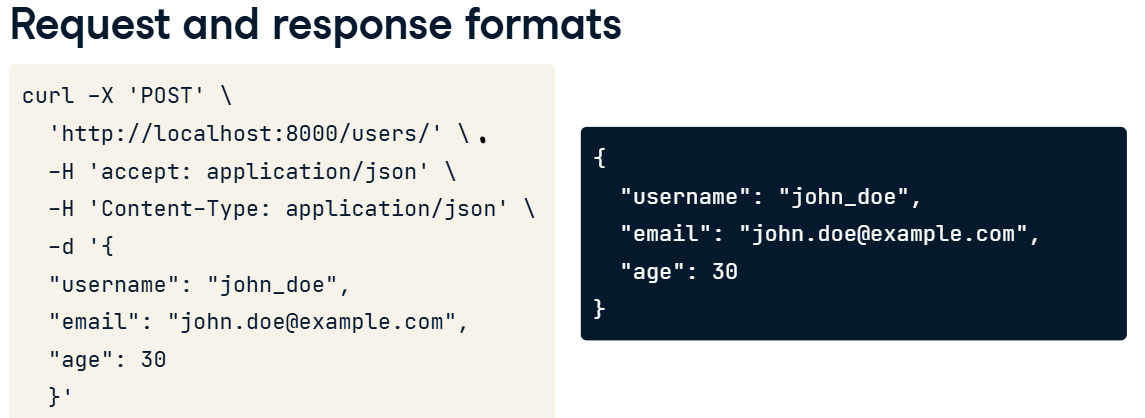

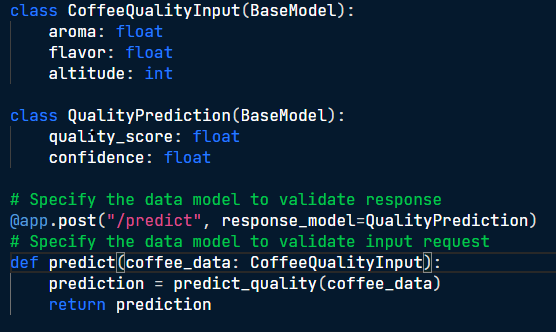

# Part 2: Integrating AI Models


## Handling different input types in FastAPI
Different models accept different types of input data.

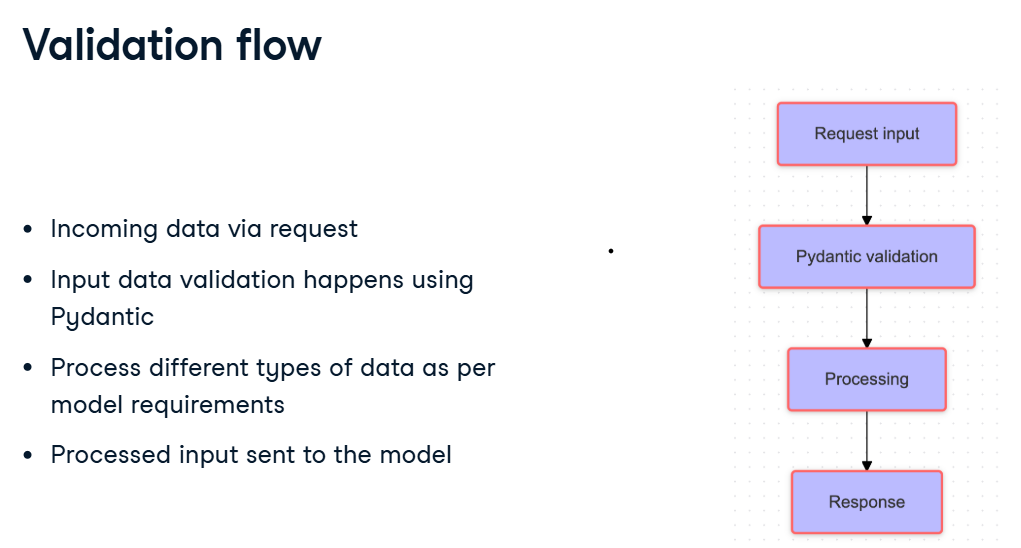

### Comment moderation system
We're going to build a content moderation system. To implement this, we'll need to handle different types of input data. Our moderation API has two main jobs. First, it processes numerical comment metric data - that contain the length of the comment, user_karma for a reputation score of the user, and report_count for the number of times that comment is reported - to score the comment using a model. Second, it processes comment text to analyze sentiment using a sentiment analysis model. Each type of data follows its own path through our API, with specific validation and processing steps.

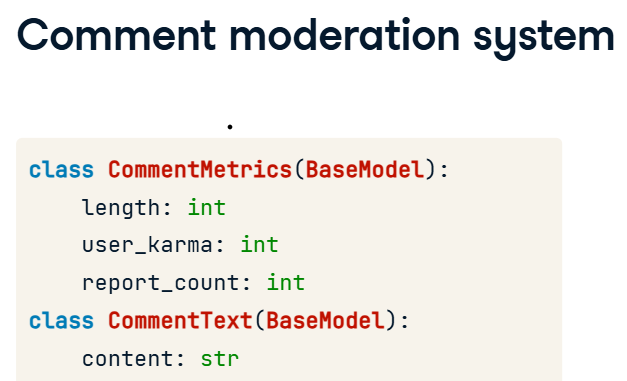

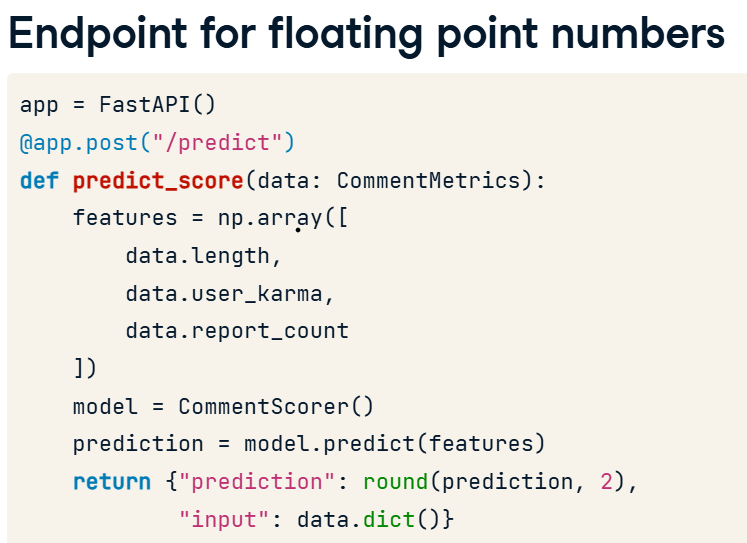

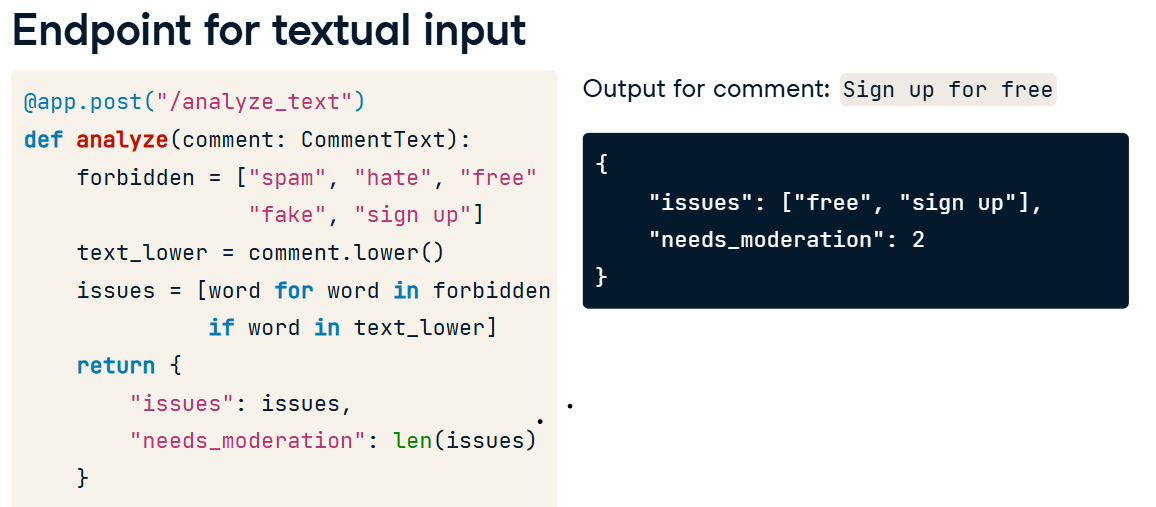

## Input Validation in FastAPI
Input validation is crucial for maintaining data integrity and preventing errors in our application. FastAPI integrates fully with Pydantic, providing powerful tools for data validation.

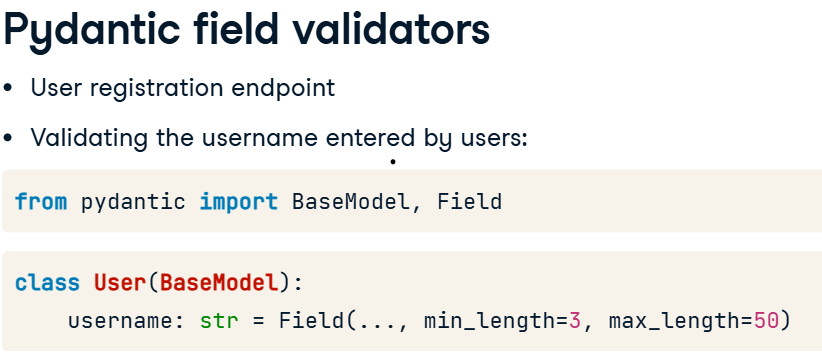

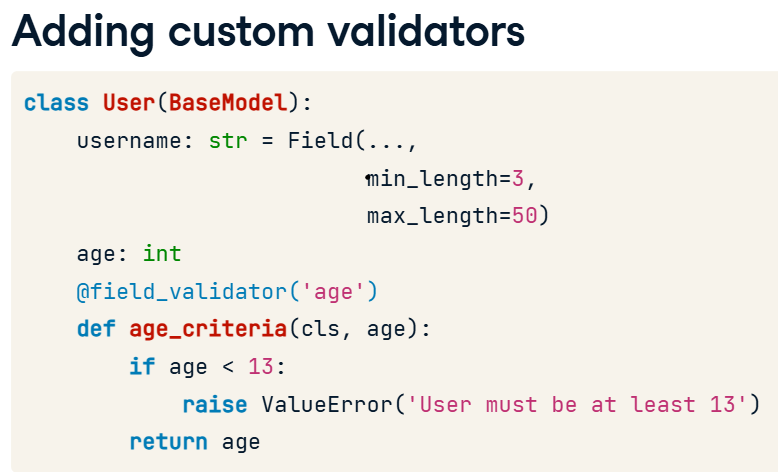

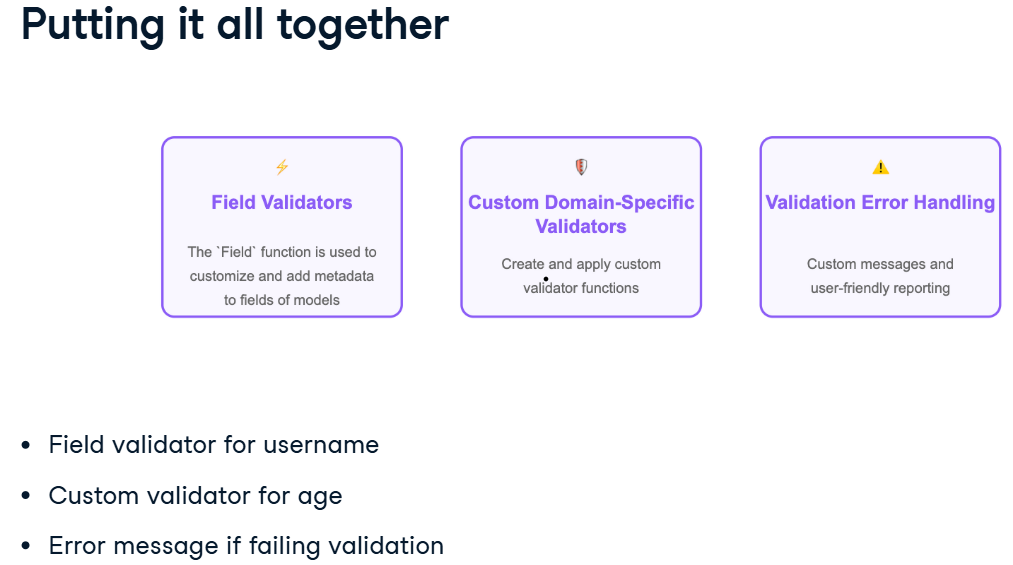

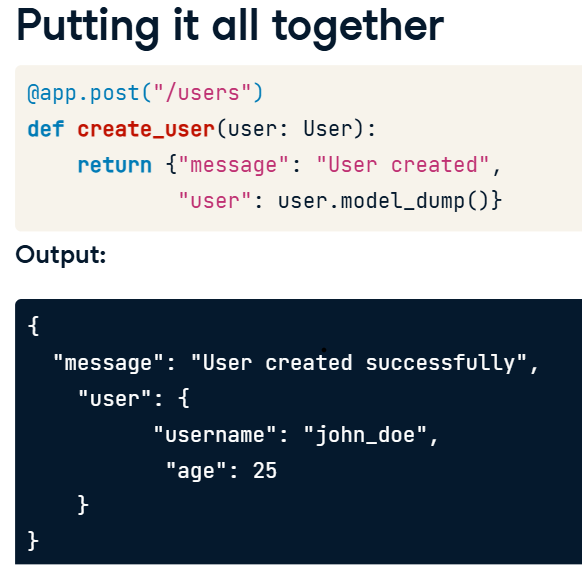

## Loading a pre-trained model
Currently, an ML model is loaded when a prediction request comes in but there is a challenge here.

Should we load our model each time a request comes in? Or is there a better way? We need our ML models to be loaded and ready to infer before the users start sending requests. Essentially, we'd want our models to load as soon as the server starts up.

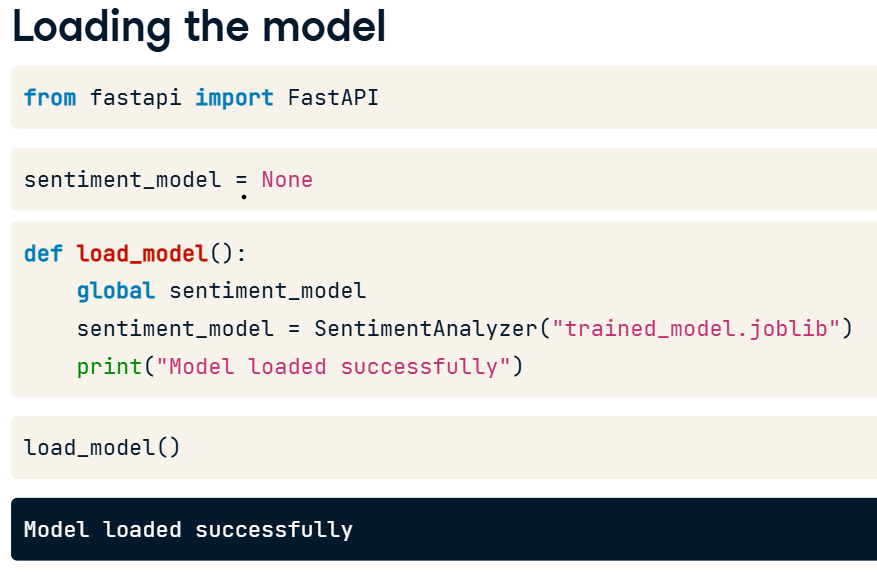

### FastAPI lifespan event

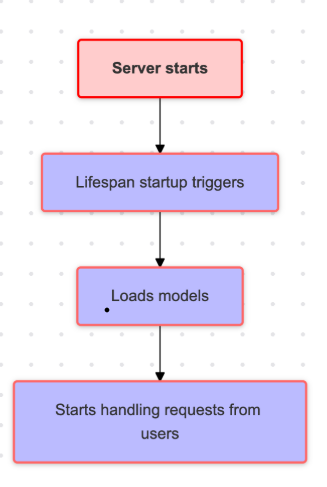

We imported the asynccontextmanager from contextlib; it is a decorator that creates an asynchronous context manager. We define our lifespan function that takes the FastAPI app as a parameter and uses a yield statement to ensure resources are properly initialized. This is so that everything before the yield statement runs during app startup, calling the previously defined load_model() function. And to run this, we pass our lifespan function to FastAPI's constructor using the lifespan parameter. That's all we need - FastAPI handles the rest, ensuring our resources are properly managed throughout our app's lifecycle!

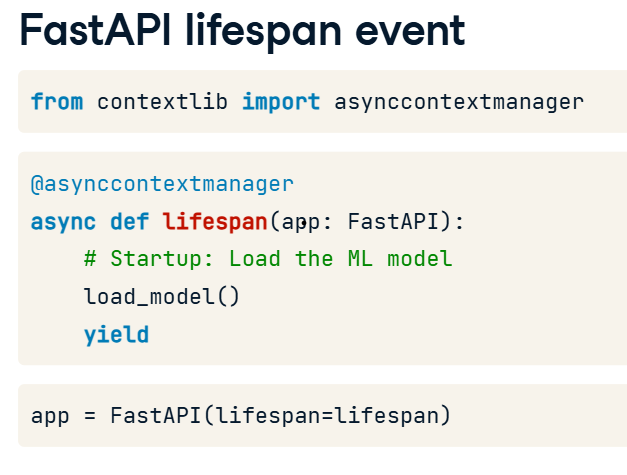

### Health check
Before we start receiving requests, we need a way to check if our API is ready and has the model loaded or not. That's why we add a health check endpoint. We check if the model is loaded or not and return healthy status when the model is available to make predictions, and unhealthy status when the model isn't available. To test the endpoint, we can send a GET request at the local server using the curl command.

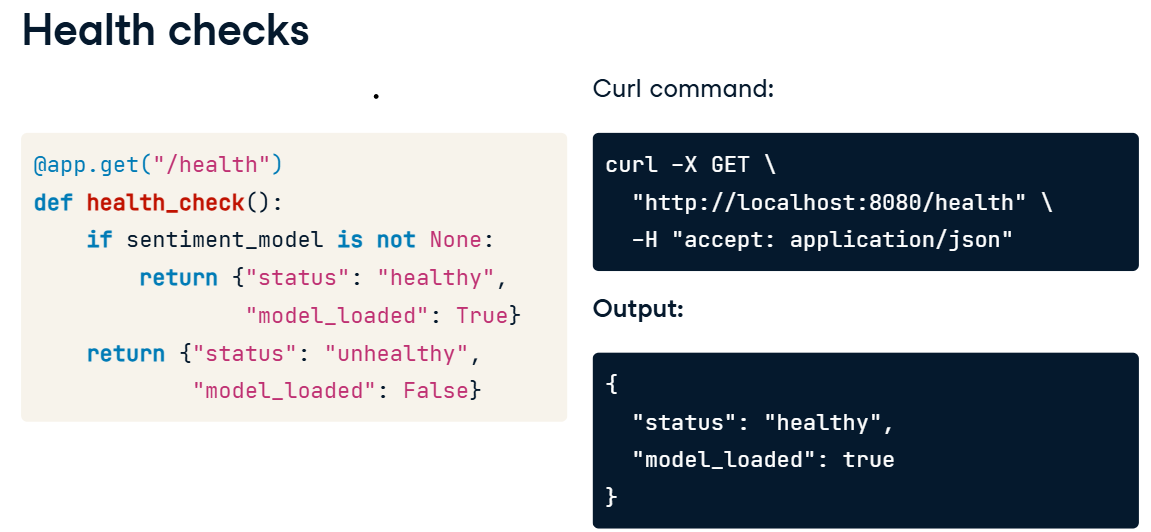

## Returning structured prediction response

### Challenges with deploying models
Whenever we are deploying ML models, it's not enough to just make predictions. We need to accept input data properly, validate it before prediction, handle errors gracefully and return the predictions from models as structured responses. Let's see how FastAPI can help us do this.

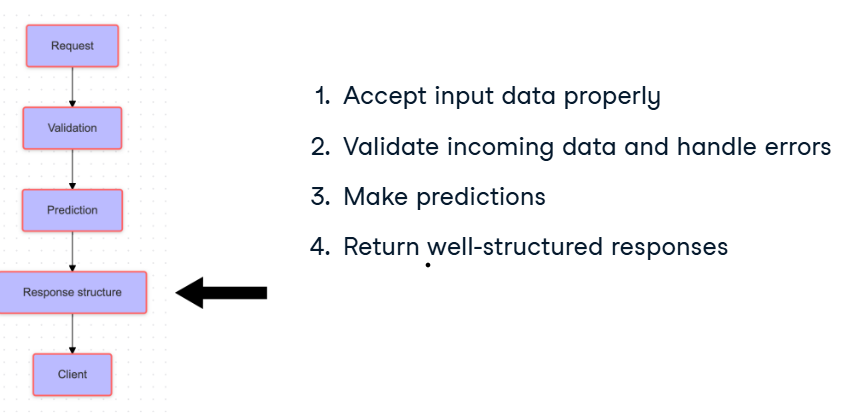

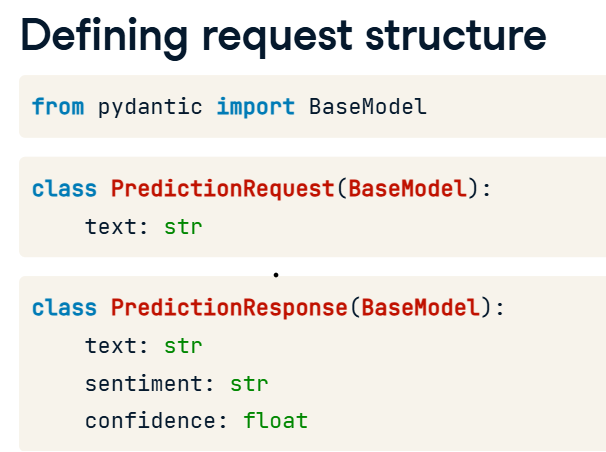

### Creating the prediction endpoint
Incoming data in a POST request needs to be validated, and FastAPI automatically converts the incoming JSON request into a PredictionRequest object.

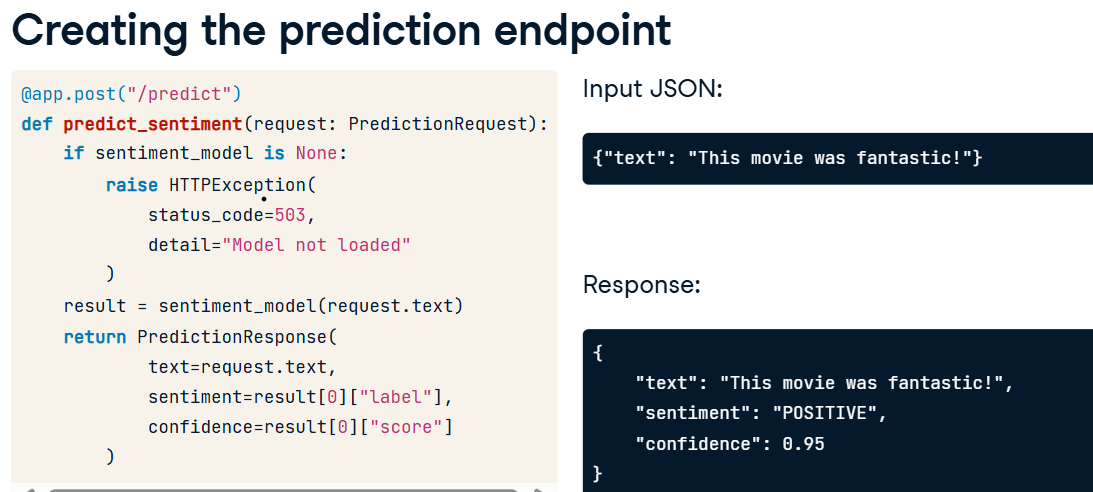

### Error handling
We can further add a try-except block to handle any error that comes up while making predictions

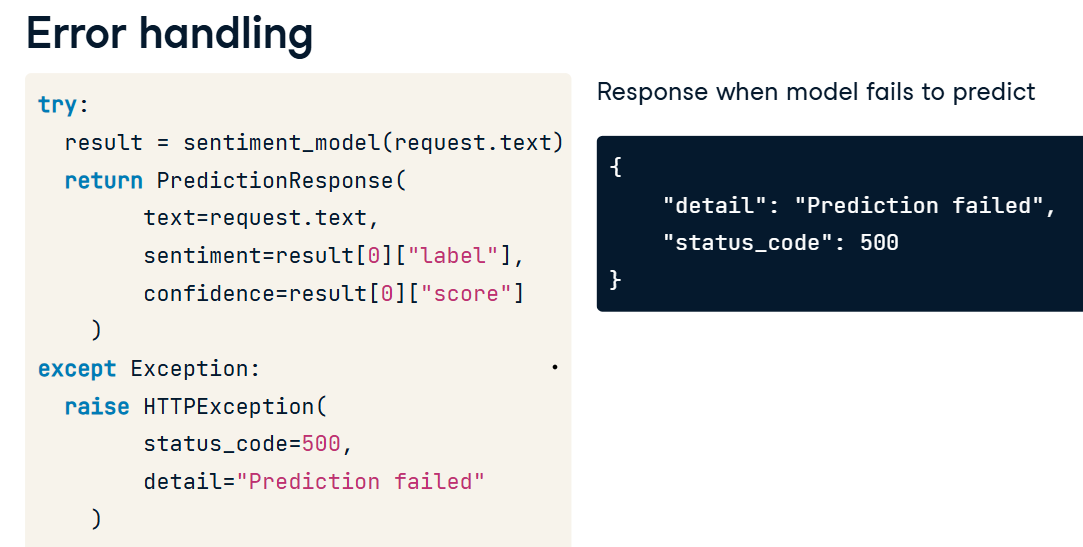

### Testing the endpoint
To test our endpoint, we can use the curl command or the requests python library.

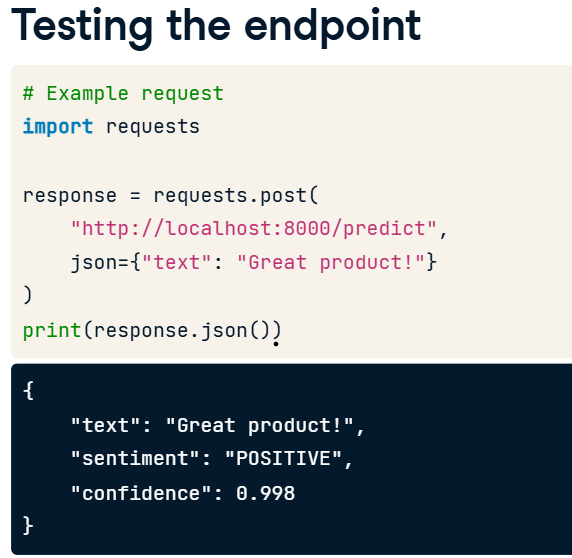

# Part 3: Securing and Optimizing the API


## API key authentication
### Understanding APIKeyHeader
FastAPI provides a specialized class to define and extract API keys in request headers called APIKeyHeader. We set 'name' to specify which header field contains our key. In this case, we will be looking for an API key named X-API-Key in the request header. 'auto_error=True' ensures FastAPI automatically handles missing keys.

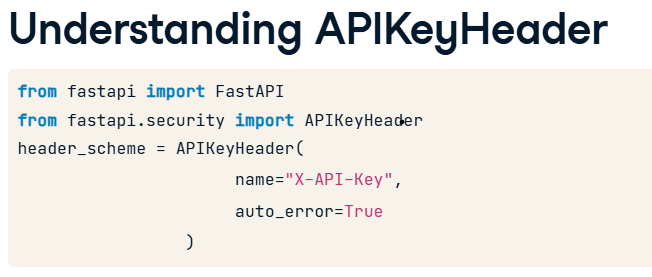

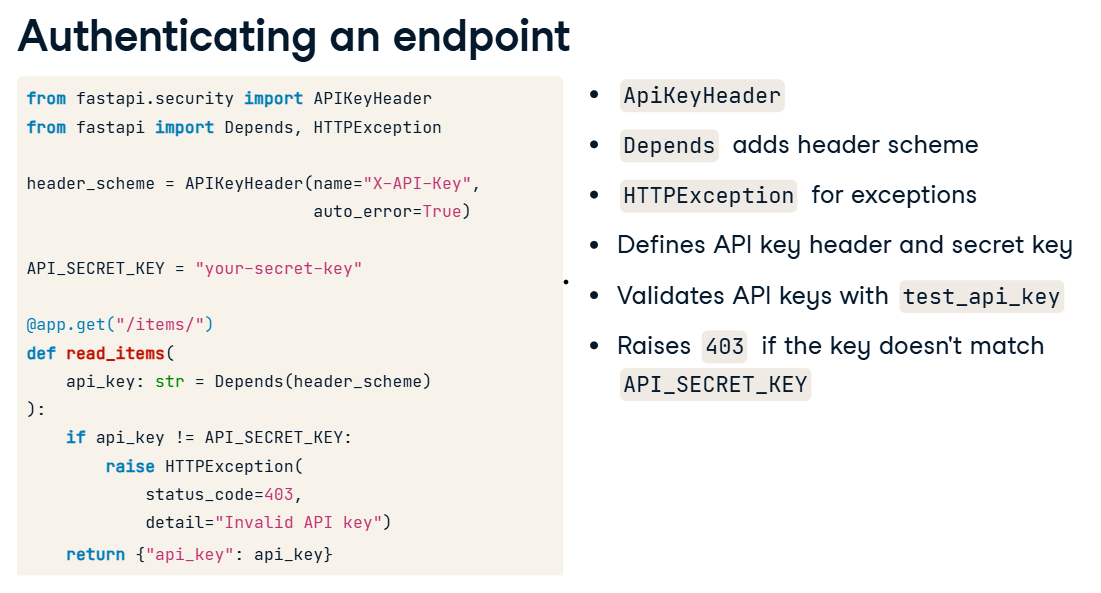

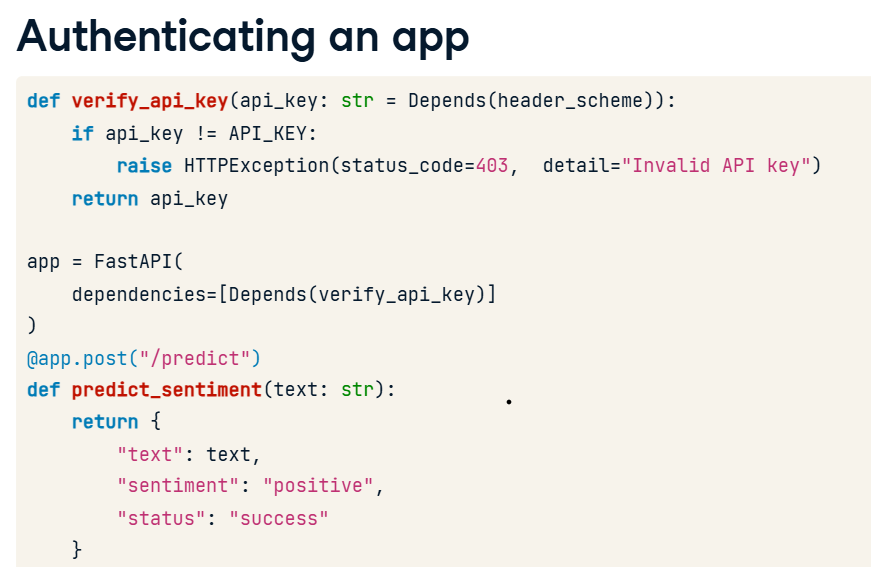

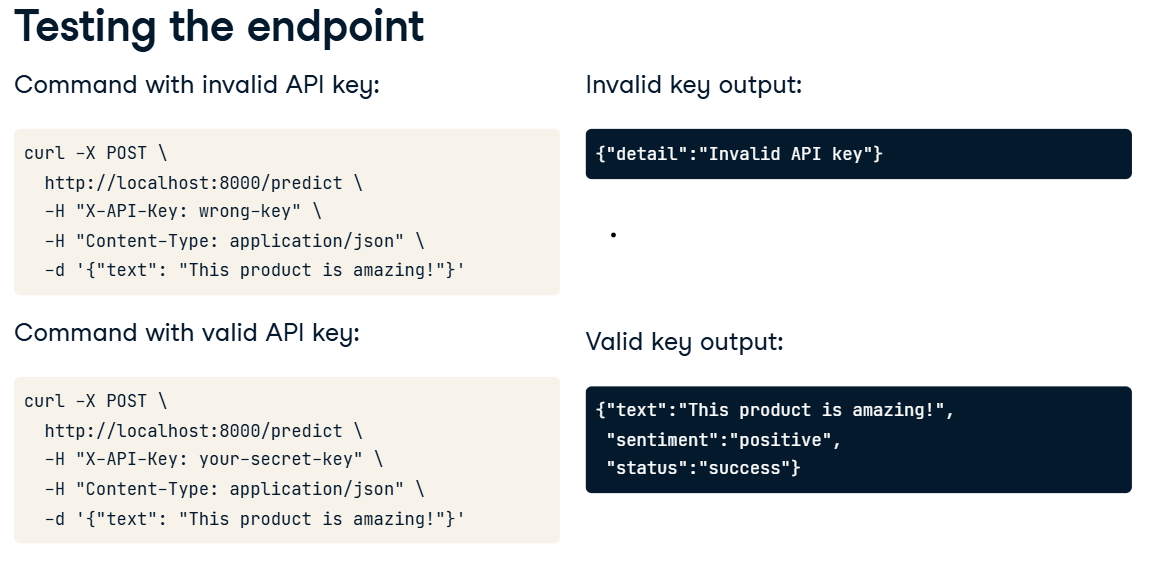

## Rate limiting
Think of rate limiting like a traffic light - it helps control the flow of requests to prevent overload. It controls the frequency of API requests to prevent abuse and ensure fair usage. It raises HTTP 429 ("Too Many Requests") when the limit is exceeded.

We secure our API using two essential layers of protection. When a client sends a request to our API, it goes through two security checkpoints:
First, the API key authentication. If we provide a valid API key, we can proceed. If not, we'll receive a 403 Unauthorized error.
Second, assuming our API key is valid, we the check rate limit.

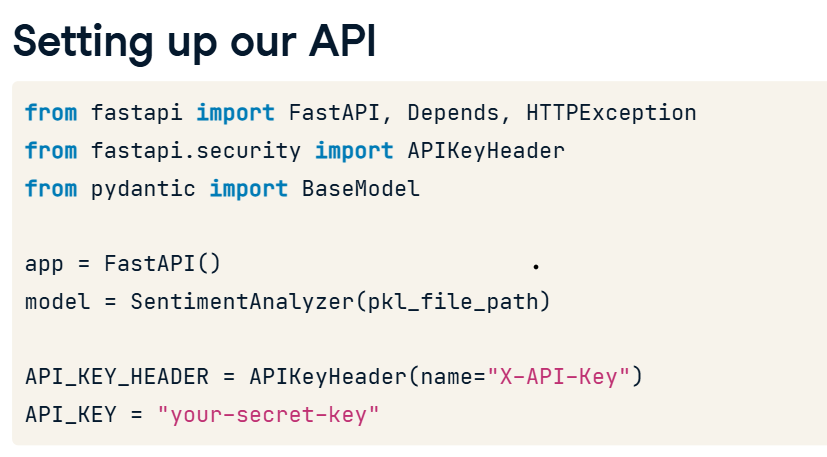

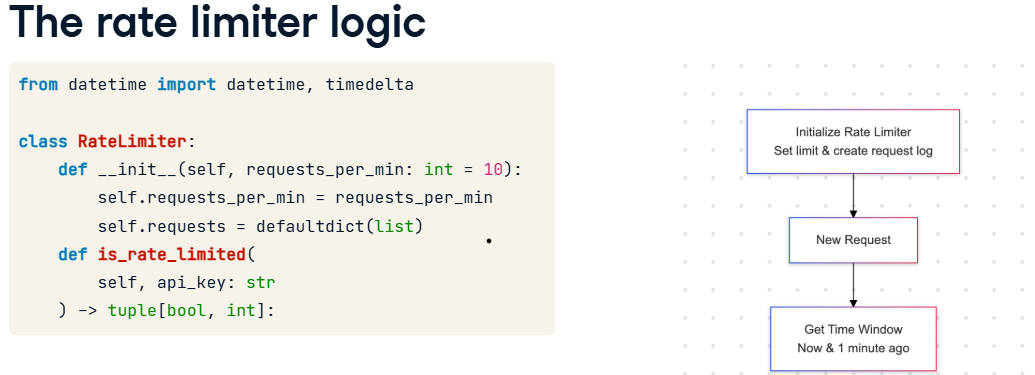

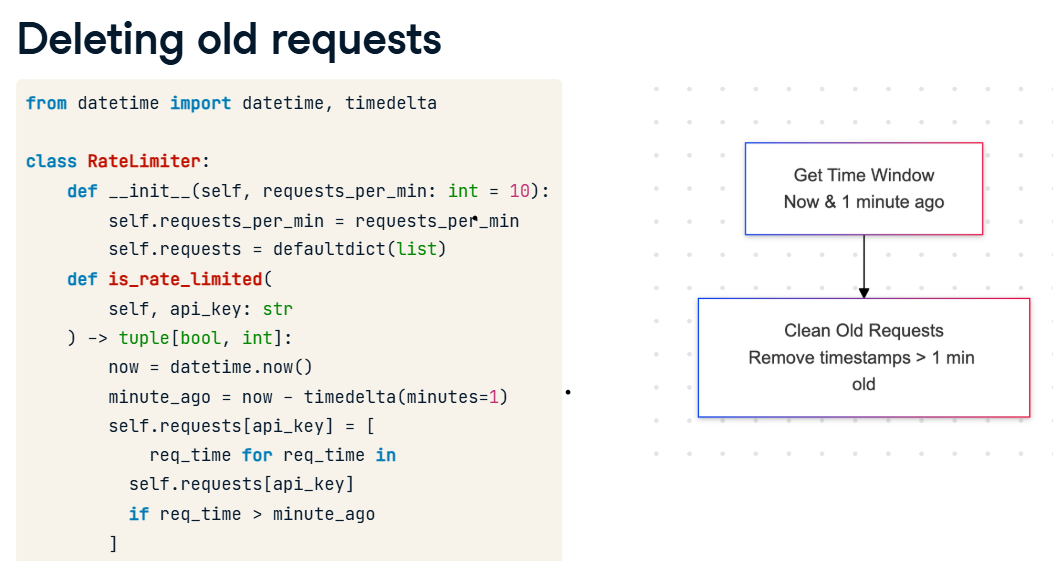

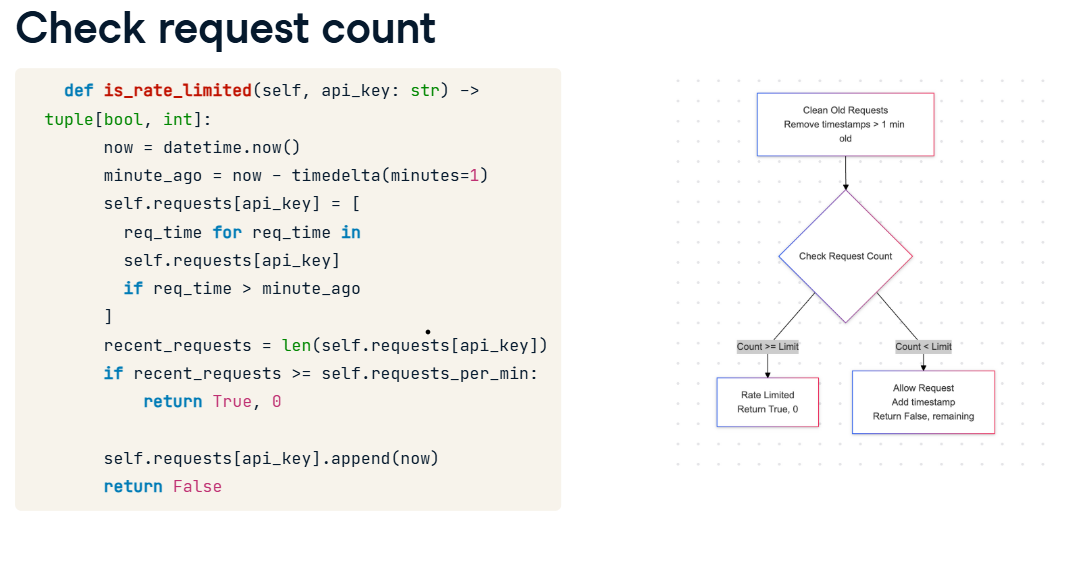

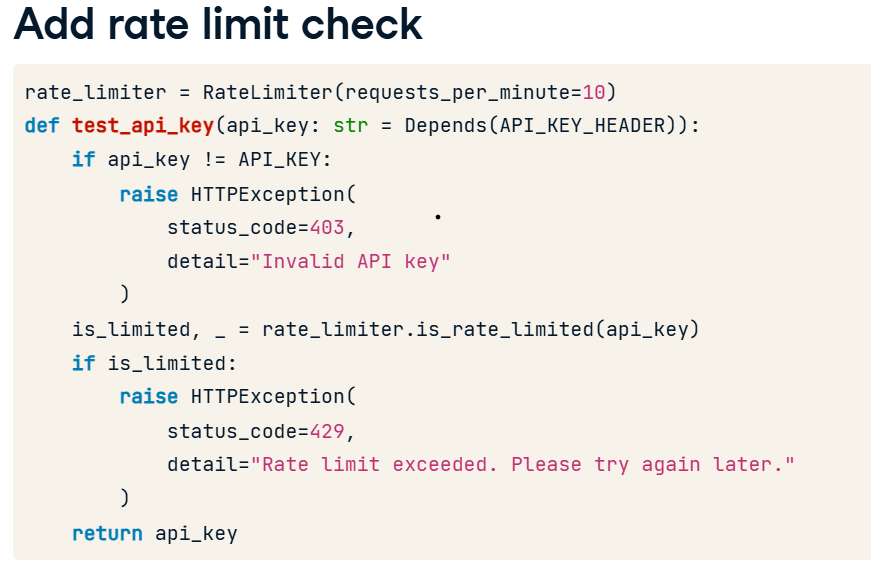

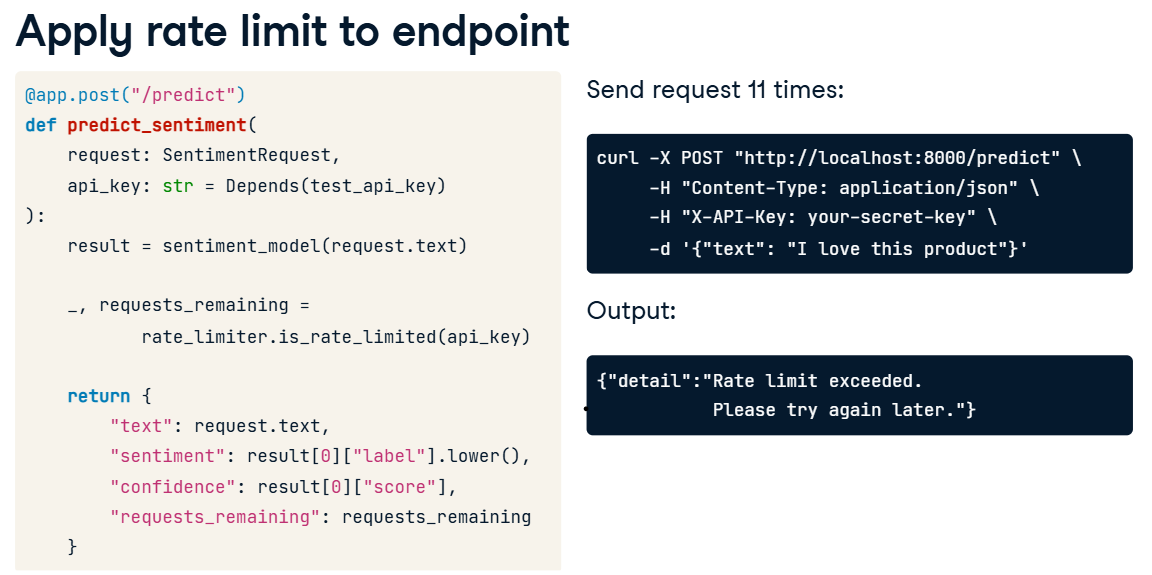

## Asynchronous Processing
The synchronous code blocks other operations until completion, while async allows other operations to continue. We use asyncio, which is a Python library for processing concurrent requests using async and await syntax.

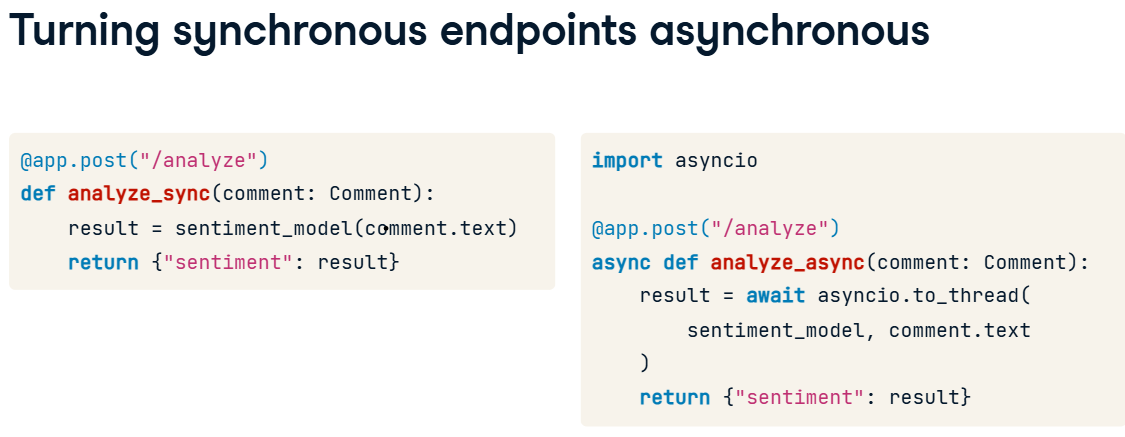

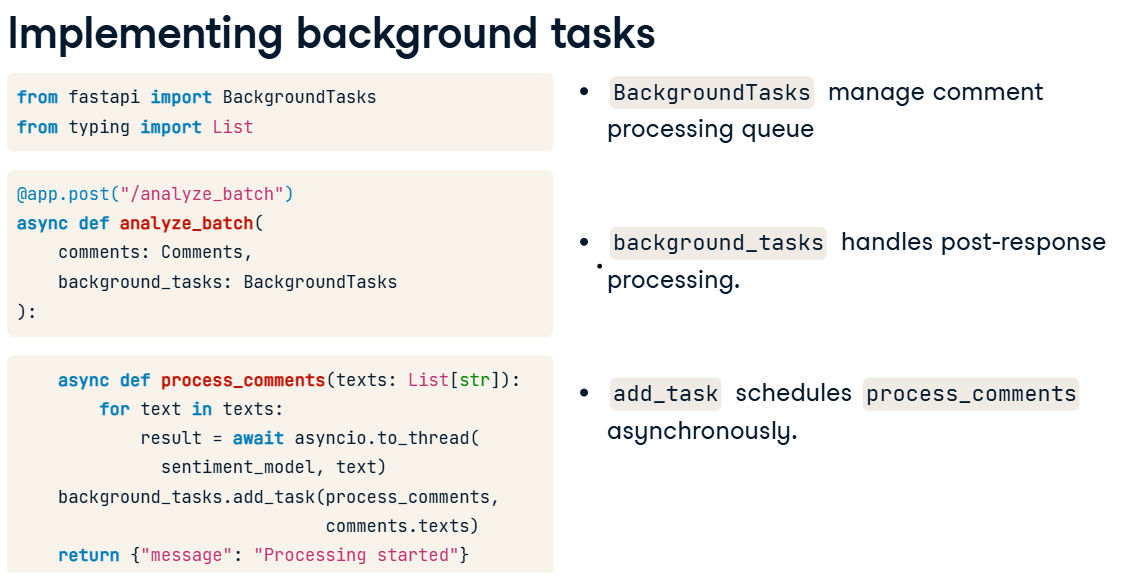

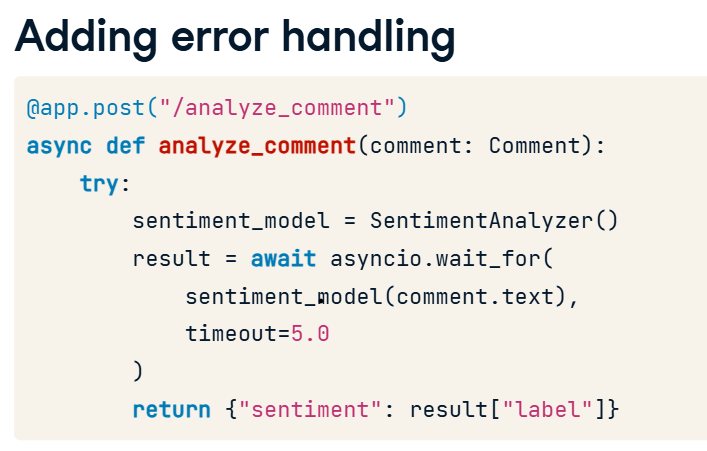
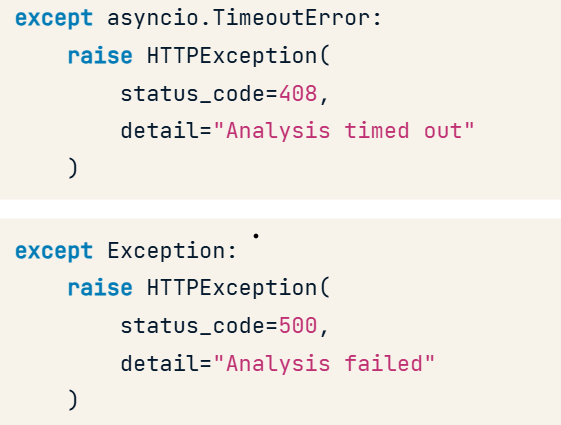